# ChirpInterleaved

In [16]:
import os
import numpy as np
from matplotlib import pyplot as plt
from pathlib import Path

In [17]:
import sys

sys.path.append(str(Path('../..').parent))

from utils import plot_stim

In [18]:
import yaml

with open('../../config.yaml', 'r') as f:
    config = yaml.safe_load(f)

In [19]:
qdspy_export_dir = Path(config["qdspy"]["export_dir"])
os.listdir(qdspy_export_dir)

['Chirp_Interleaved_60Hz_10um_pixels.mp4',
 'Chirp_Interleaved_60Hz_10um_pixels.npz',
 'Chirp_Interleaved_60Hz_10um_pixels_mark.npz']

In [20]:
out_dir = Path(config["output_dir"])
os.makedirs(out_dir, exist_ok=True)

In [21]:
pixel_size_um = 10

crop_setup1_h = config["qdspy"]["crop"]["setup1"]["h"]
crop_setup1_v = config["qdspy"]["crop"]["setup1"]["v"]

crop_setup3_h = config["qdspy"]["crop"]["setup3"]["h"]
crop_setup3_v = config["qdspy"]["crop"]["setup3"]["v"]

In [22]:
chirpInt_file = 'Chirp_Interleaved_60Hz_10um_pixels.npz'
chirpInt_mark_file = 'Chirp_Interleaved_60Hz_10um_pixels_mark.npz'

In [23]:
chirpInt = np.load(os.path.join(qdspy_export_dir, chirpInt_file))['data']
chirpInt = np.round(np.mean(chirpInt, axis=-1)).astype(int)
chirpInt.shape

(4080, 120, 120)

In [24]:
chirp_mark = np.load(os.path.join(qdspy_export_dir, chirpInt_mark_file))['data']
chirp_mark = np.append(chirp_mark[:-1] & (~chirp_mark[1:]), False)
chirp_mark

array([False, False, False, ..., False, False, False], shape=(4080,))

In [25]:
time_chirp = np.arange(chirpInt.shape[0]) * 1./60. - 1

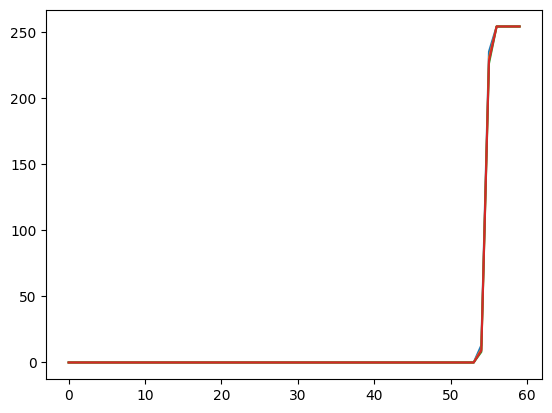

In [26]:
# Checking that the chirp is centered correctly

t_s = 4
x_center = chirpInt.shape[1]//2
y_center = chirpInt.shape[2]//2

plt.plot(chirpInt[int(60*t_s), y_center:, x_center][::-1])
plt.plot(chirpInt[int(60*t_s), :y_center, x_center])
plt.plot(chirpInt[int(60*t_s), y_center, x_center:][::-1])
plt.plot(chirpInt[int(60*t_s), y_center, :x_center])

plt.show()

In [27]:
# No rotation / flips necessary as stimulus is point-symmetric. Just cropping to the same size as the other stimuli.
chirpInt_setup1 = chirpInt[:, crop_setup1_v:-crop_setup1_v, crop_setup1_h:-crop_setup1_h]
chirpInt_setup3 = chirpInt[:, crop_setup3_v:-crop_setup3_v, crop_setup3_h:-crop_setup3_h]

In [28]:
stim_dict = {
    ('chirpInt', '1'): chirpInt_setup1,
    #('chirpInt', '3'): chirpInt_setup3,  # Same on both setups
}

Plotting chirpInt


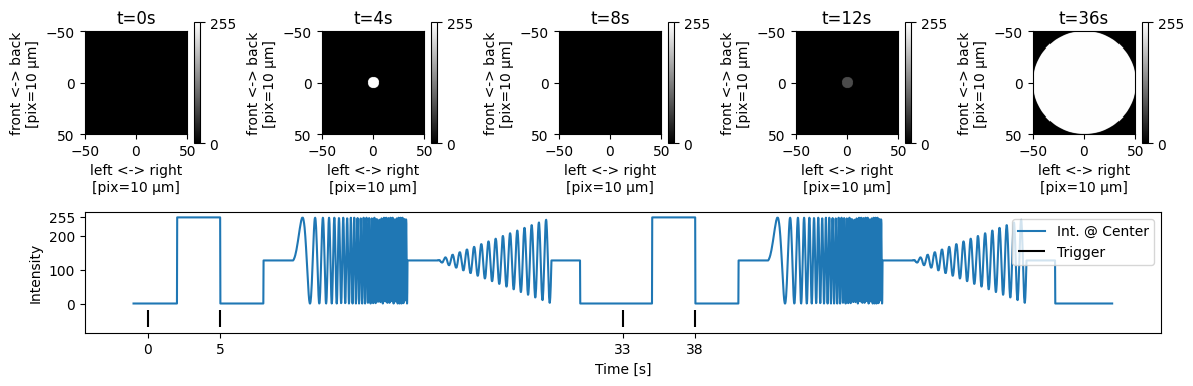

In [29]:
t_s_plot = (0, 4, 8, 12, 36)

for (name, setup), stim in stim_dict.items():
    print(f'Plotting {name}')
    
    fig, axs = plot_stim(stim, chirp_mark, time_chirp, t_s_plot=t_s_plot)
    plt.savefig(os.path.join(out_dir, f'{name}.pdf'), bbox_inches='tight')
    plt.show()

In [30]:
target_freq = 60
assert np.isclose(target_freq, np.round(1 / np.mean(np.diff(time_chirp))))

for (name, setup), stim in stim_dict.items():
    
    assert np.all(stim.astype(np.uint8) == stim)
    np.savez_compressed(
        os.path.join(out_dir, f'{name}_movie_and_trigger'),
        stimulus=stim.astype(np.uint8),
        time=time_chirp.astype(np.float32),
        trigger=chirp_mark,
        framerate=target_freq,
        pixel_size_um=pixel_size_um,
    )